# Animação da Propagação de Onda

Este Jupyter Notebook cria a animação de propagação de onda de um meio geológico utilizando a biblioteca [PyFWI](https://pyfwi.readthedocs.io/en/latest/index.html). 

Você pode personalizar seu modelo em:

- Parâmetros do modelo geológico
- Criar o modelo geológico personalizado
- Parâmetros da simulação

Entretanto, aconselho ler a documentação da biblioteca PyFWI para alterar estes modelos. Os comentários no código poderão te auxiliar na personalização. Contudo, aconselho a criar uma cópia deste código para manter como referência.

Observação: esta biblioteca tem algum problema com gerenciamento de memória. Toda vez que for rodar o modelo, poderá ocorrer erro. Se isto ocorrer, é necessário reinicar o kernel toda vez que for rodar a simulação!!!

Valores de vp na posição da fonte (z=0, x=400): 1500.0
Valores de rho na posição da fonte (z=0, x=400): 1800.0


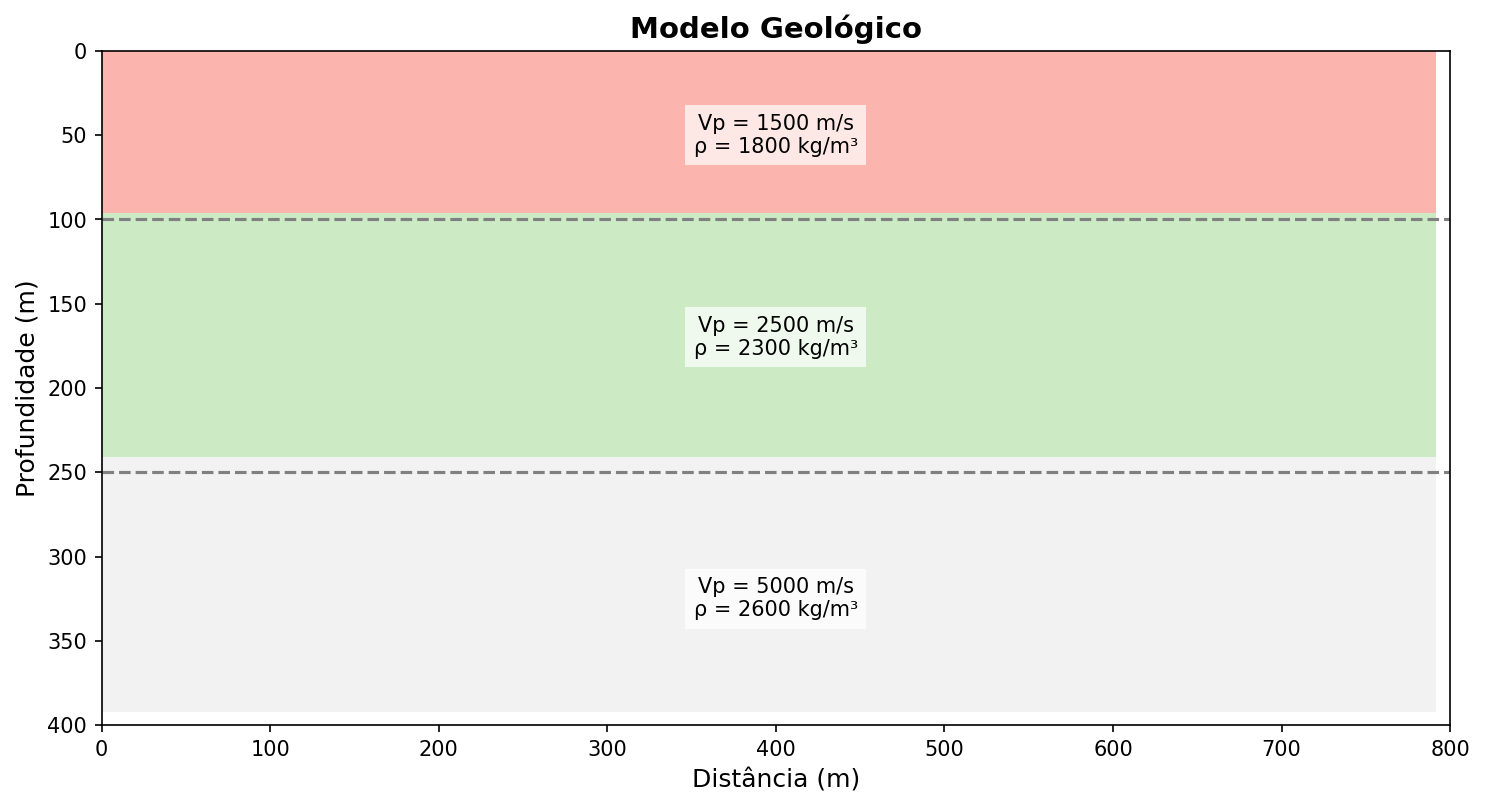

Posição da fonte (índices): [[97.  0.]]
Posição da fonte (m): 399.0 0.0
Posições dos receptores (índices): [[ 14.   0.]
 [ 21.   0.]
 [ 28.   0.]
 [ 35.   0.]
 [ 42.   0.]
 [ 49.   0.]
 [ 56.   0.]
 [ 63.   0.]
 [ 70.   0.]
 [ 77.   0.]
 [ 84.   0.]
 [ 91.   0.]
 [ 98.   0.]
 [105.   0.]
 [112.   0.]
 [119.   0.]
 [126.   0.]
 [133.   0.]
 [140.   0.]
 [147.   0.]
 [154.   0.]
 [161.   0.]
 [168.   0.]
 [175.   0.]
 [182.   0.]
 [189.   0.]
 [196.   0.]
 [203.   0.]
 [210.   0.]
 [217.   0.]
 [224.   0.]
 [231.   0.]
 [238.   0.]
 [245.   0.]
 [252.   0.]
 [259.   0.]
 [266.   0.]
 [273.   0.]
 [280.   0.]
 [287.   0.]
 [294.   0.]
 [301.   0.]
 [308.   0.]
 [315.   0.]
 [322.   0.]
 [329.   0.]
 [336.   0.]
 [343.   0.]
 [350.   0.]
 [357.   0.]
 [364.   0.]
 [371.   0.]
 [378.   0.]
 [385.   0.]
 [392.   0.]
 [399.   0.]
 [406.   0.]
 [413.   0.]
 [420.   0.]
 [427.   0.]
 [434.   0.]
 [441.   0.]
 [448.   0.]
 [455.   0.]
 [462.   0.]
 [469.   0.]
 [476.   0.]
 [483.   0.]
 [490.   

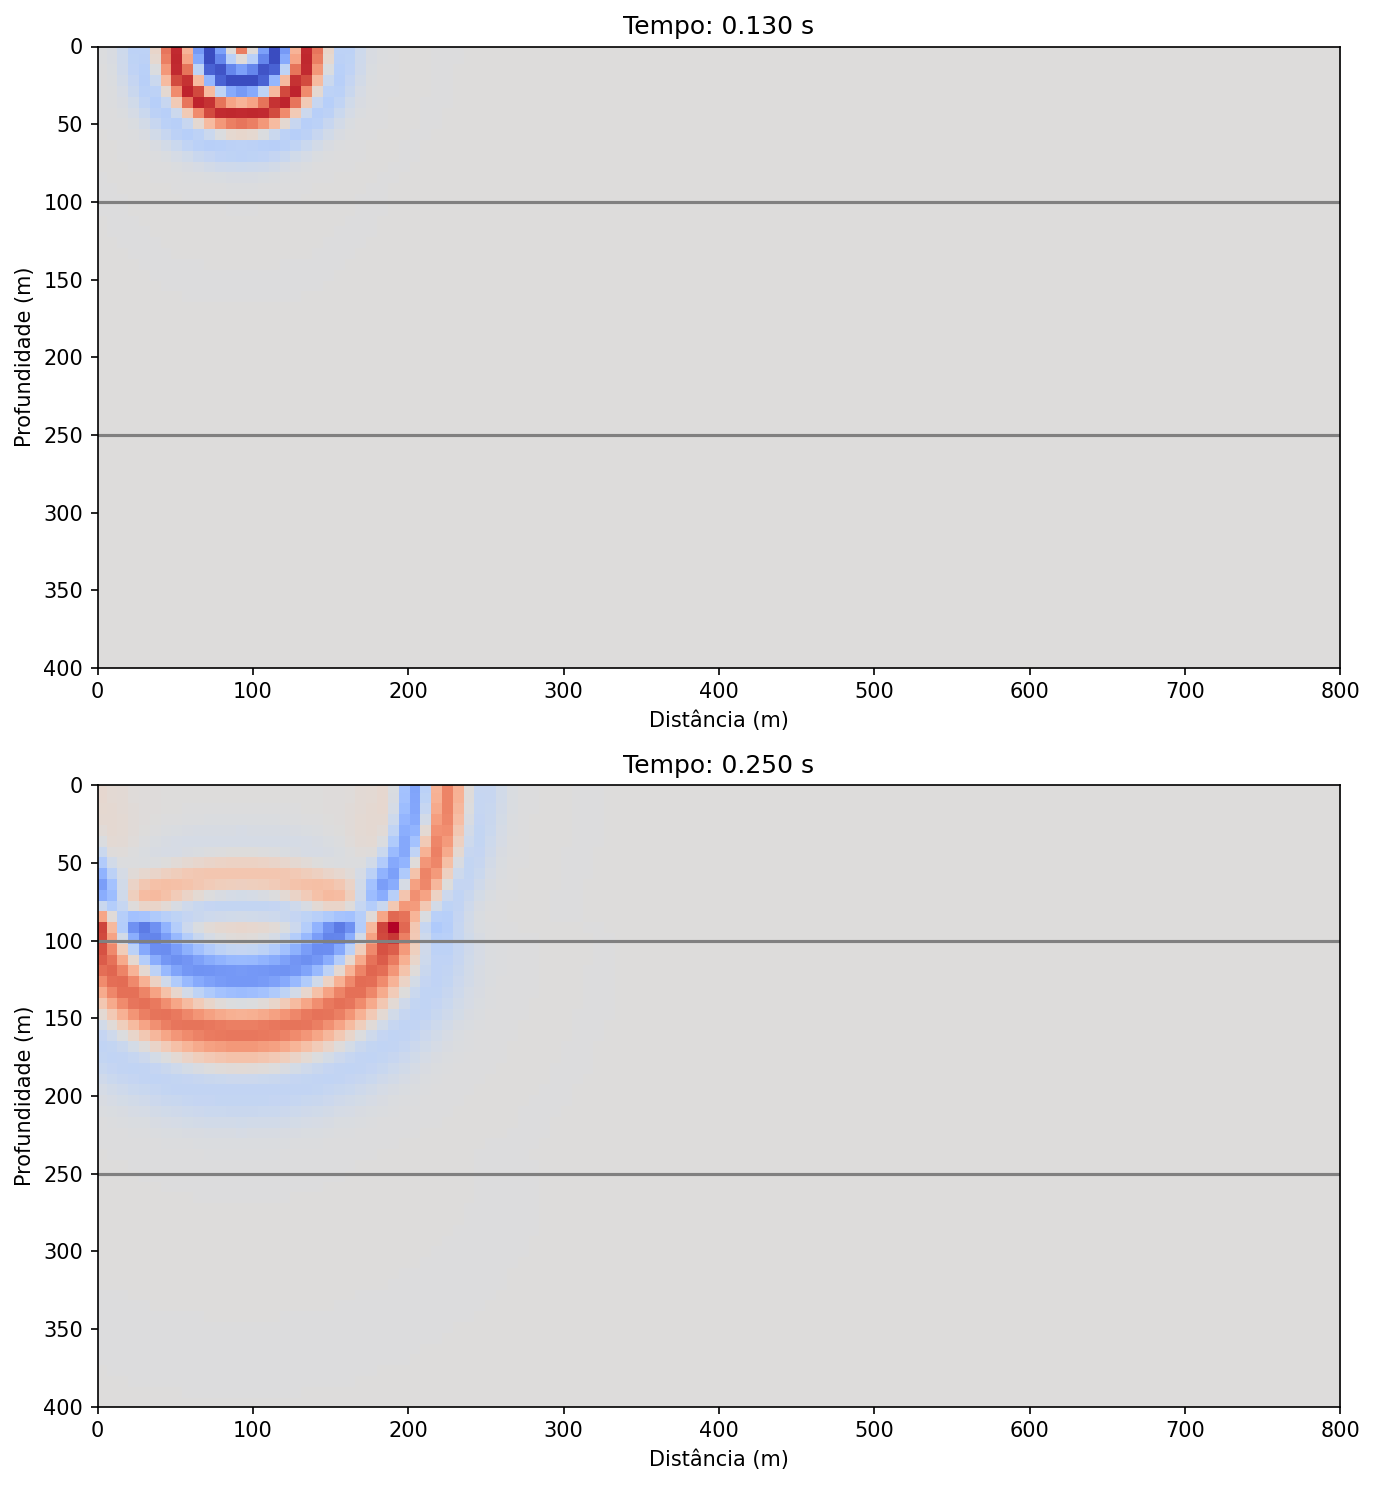

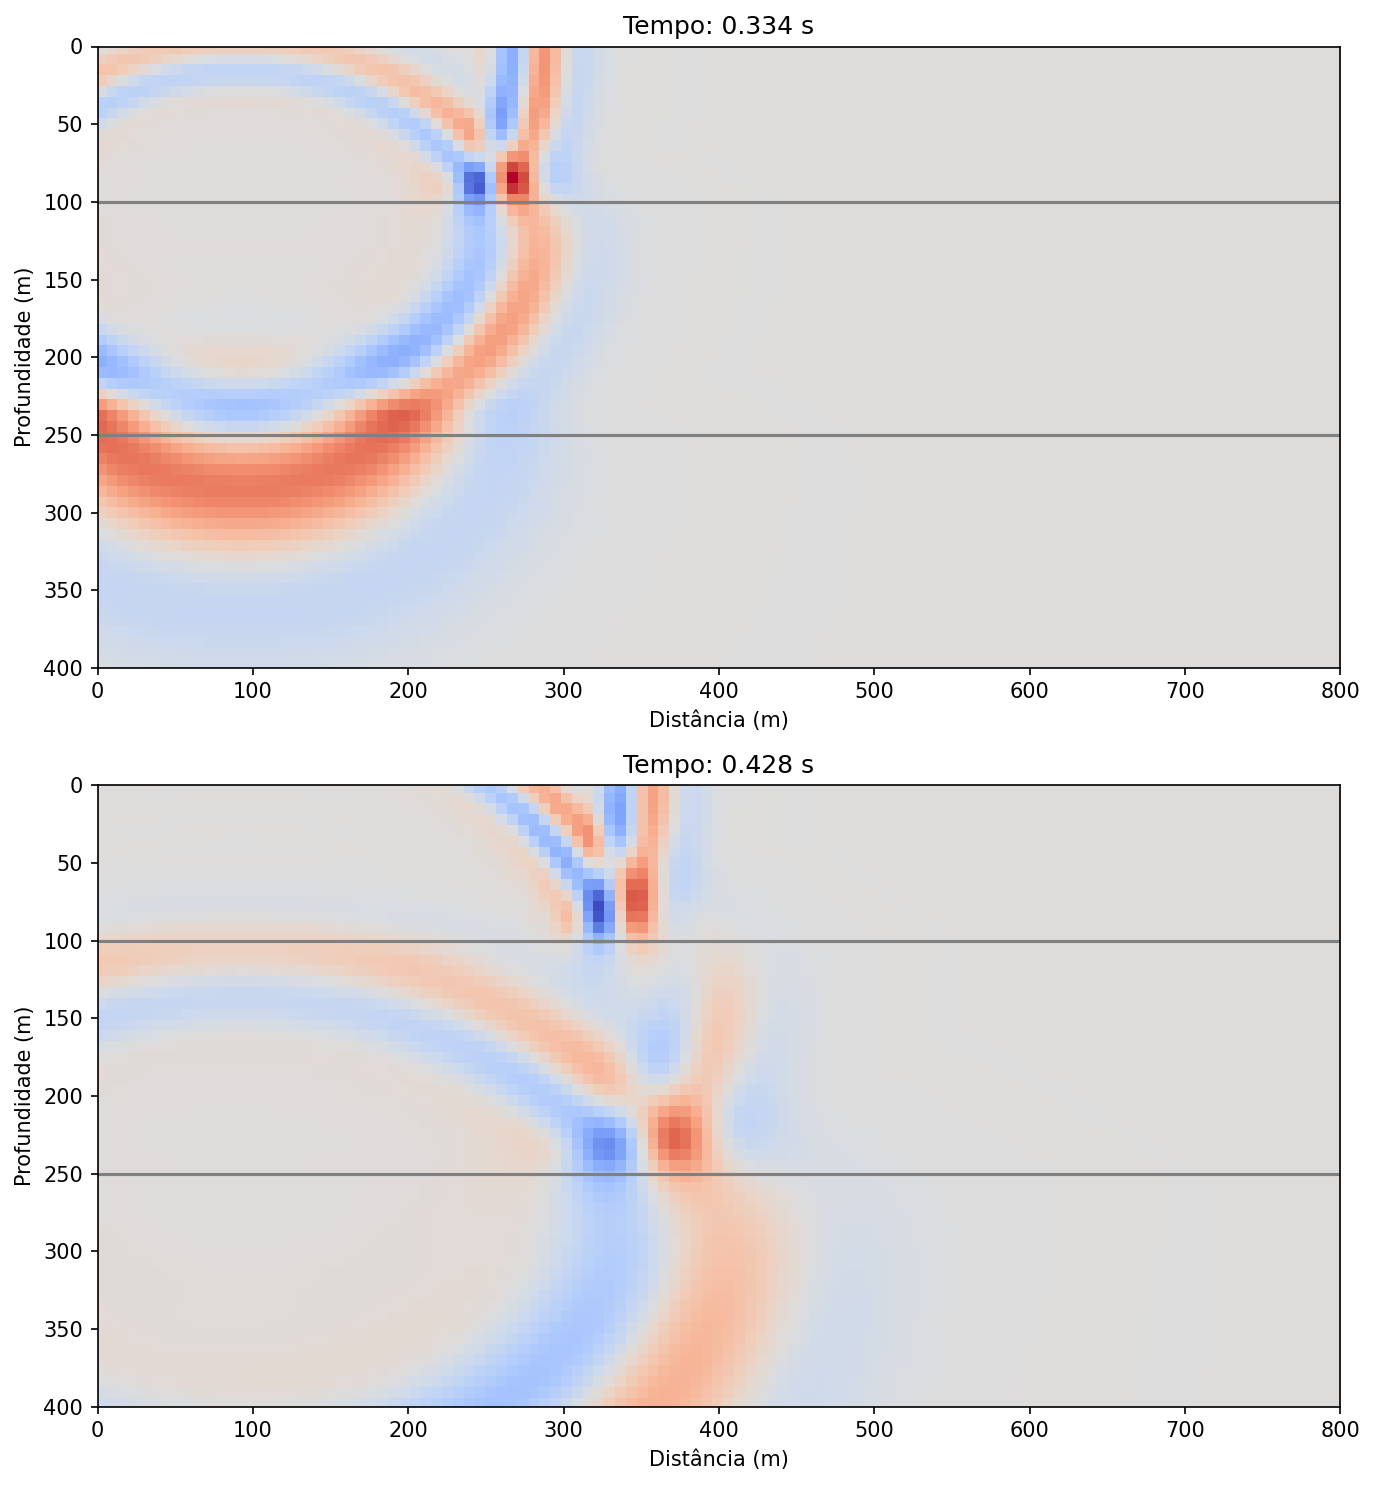

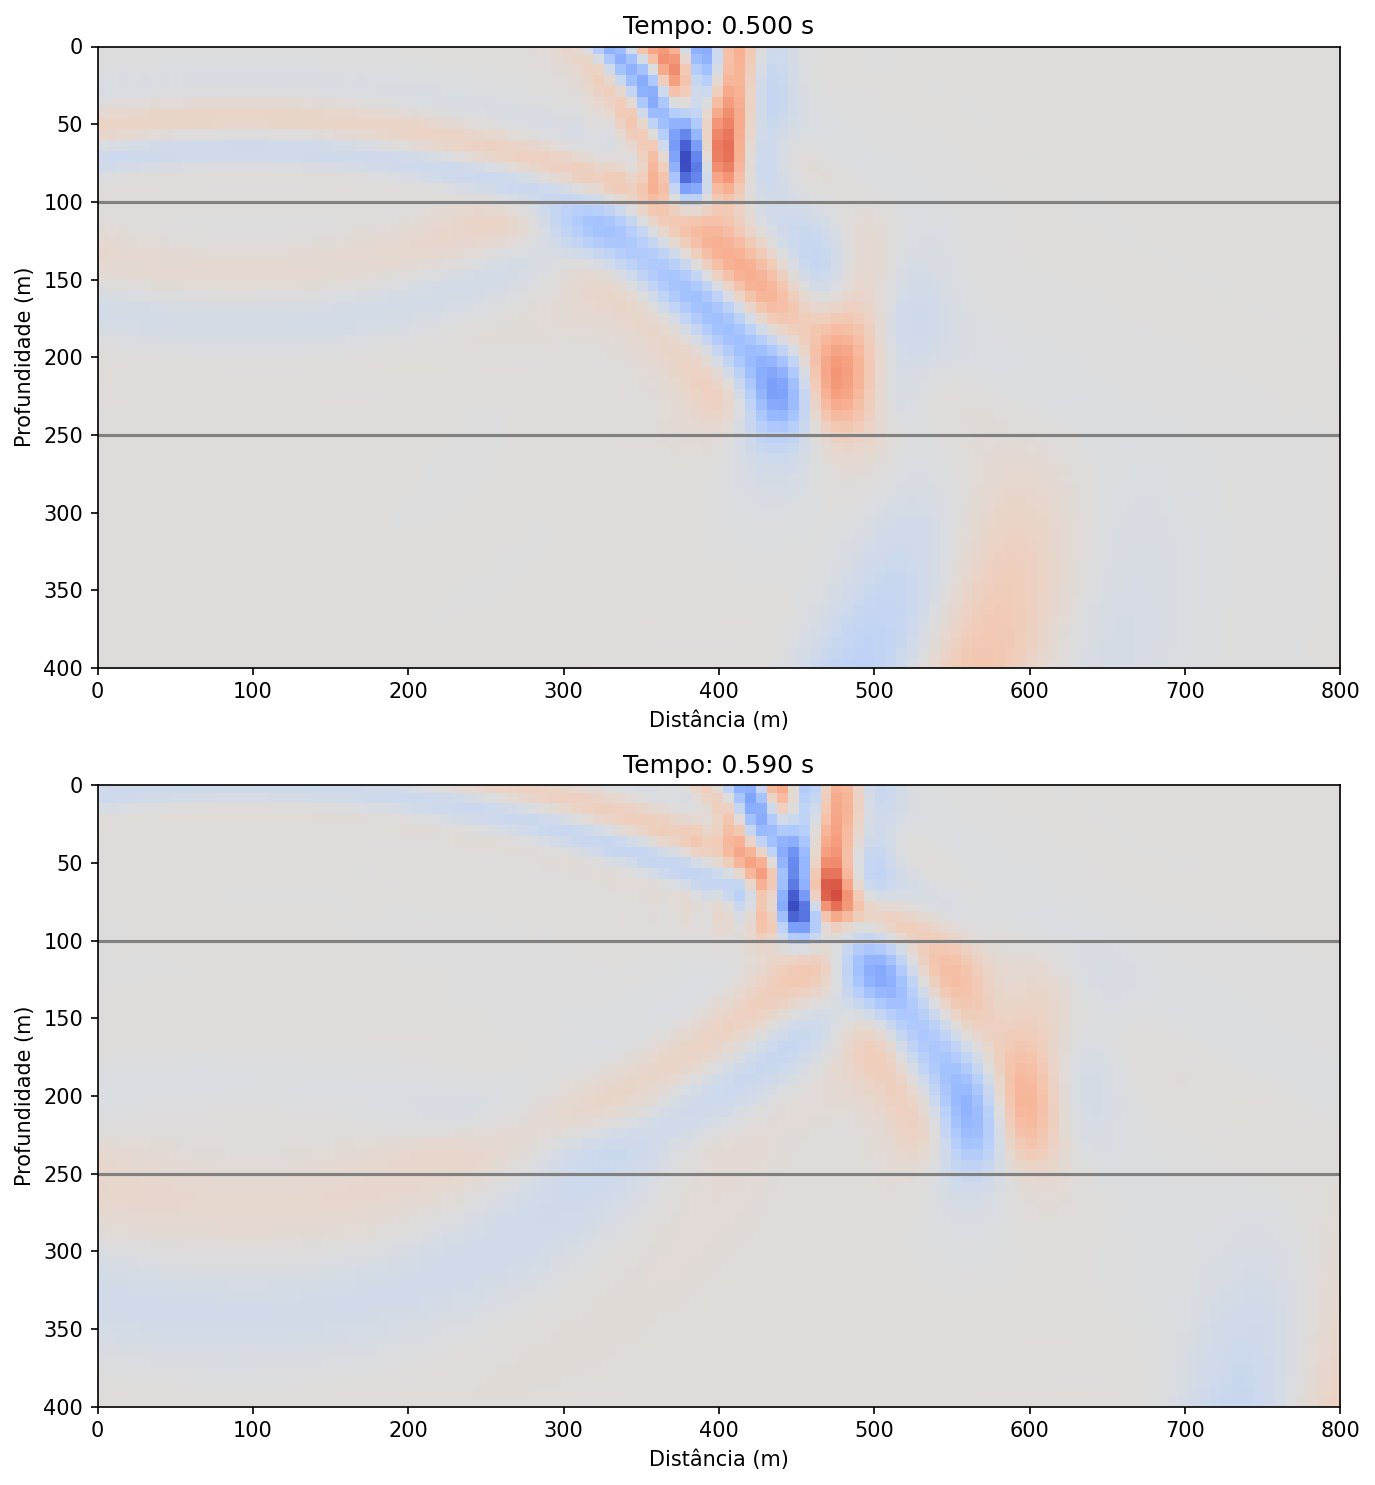

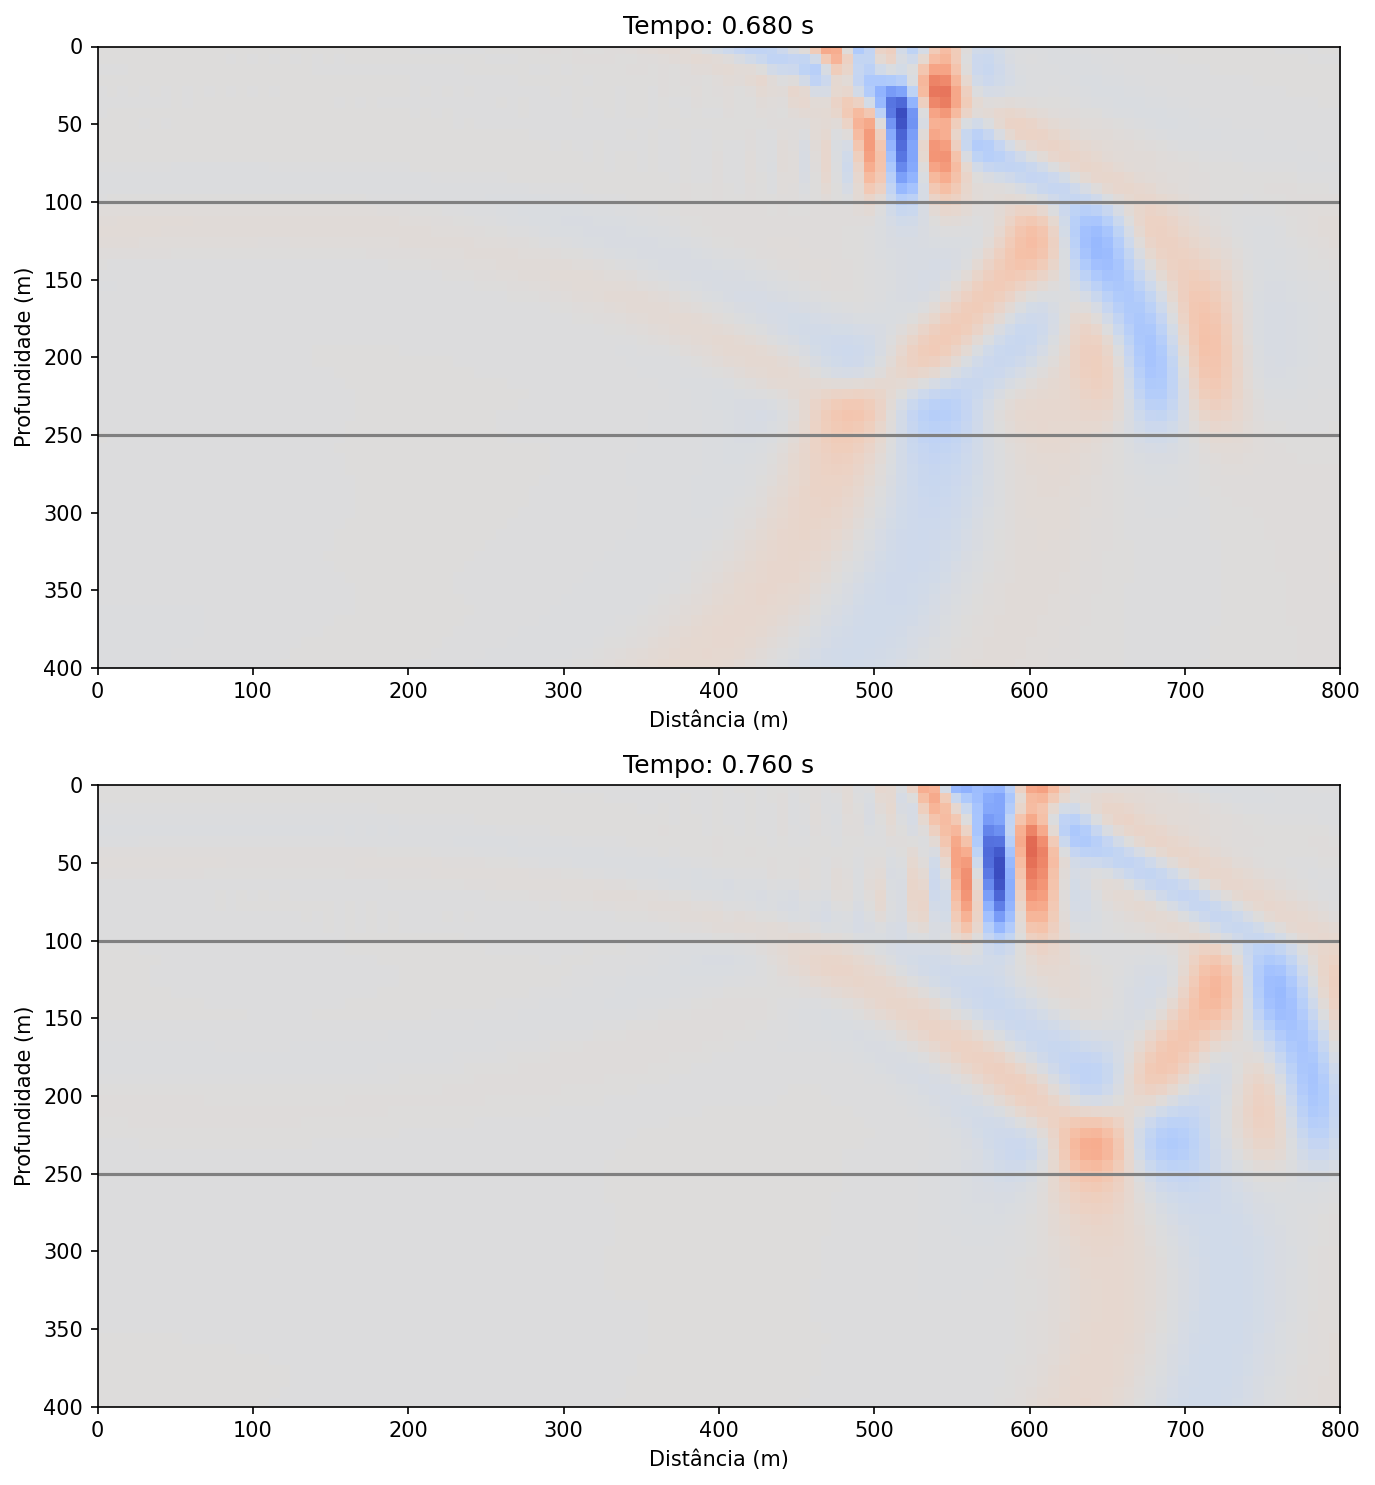

Máximo e mínimo de seismogram_agc: 5.7717505 -5.7717505


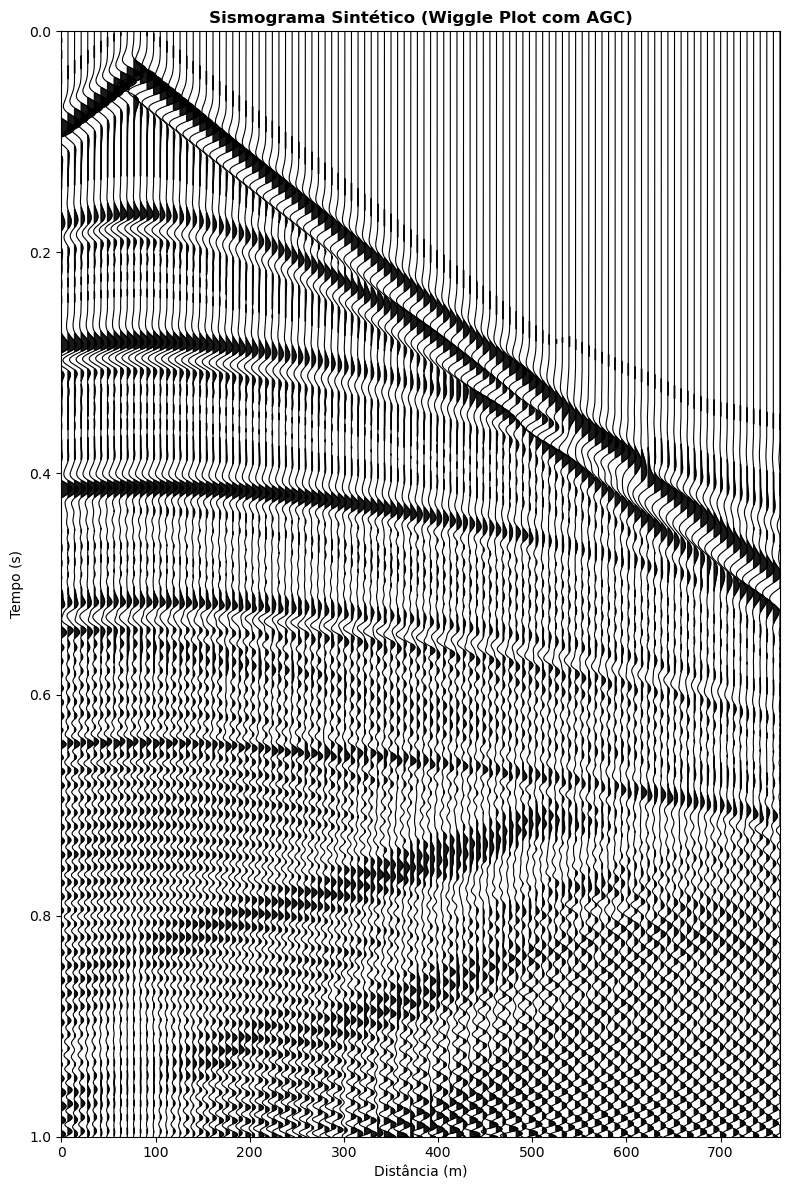

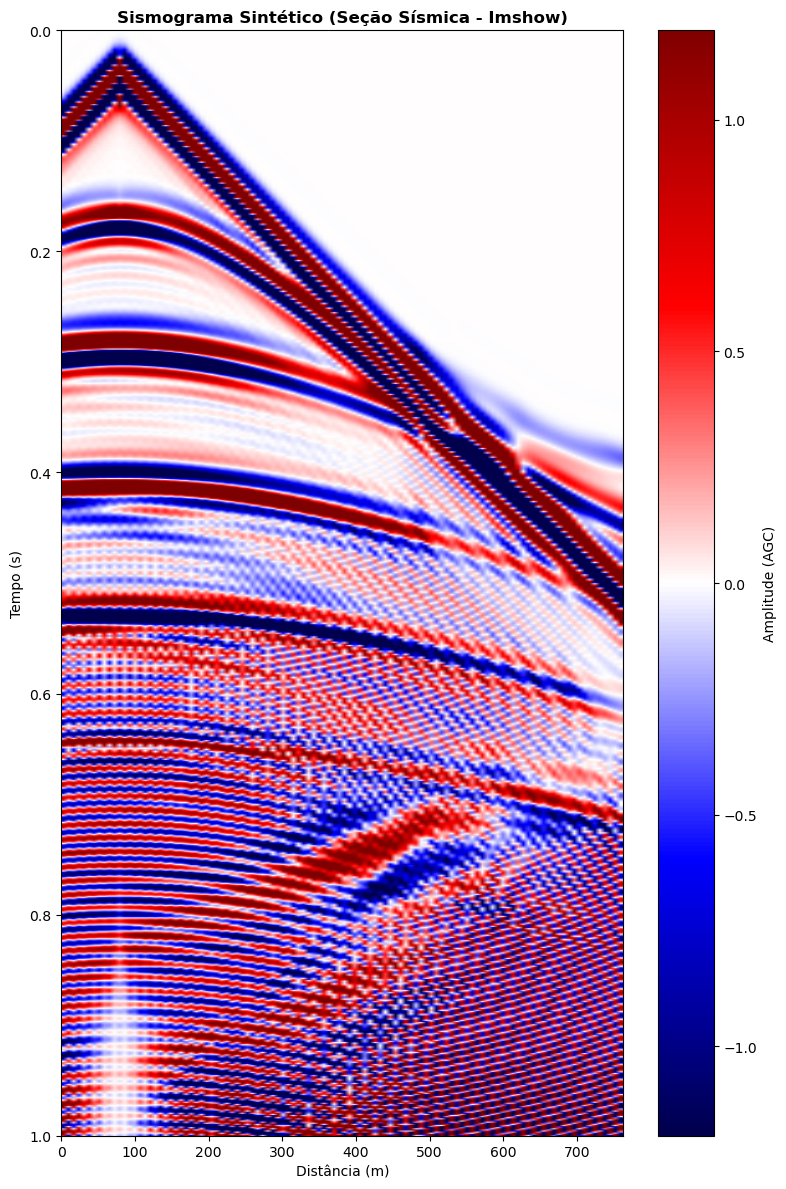

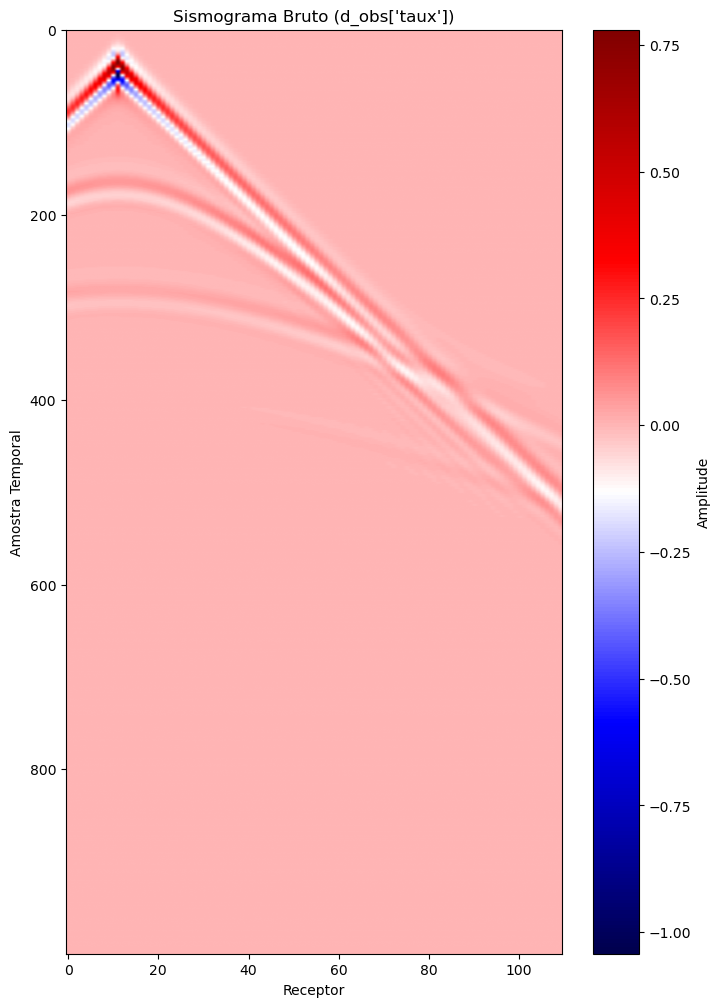

Recursos OpenCL liberados.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import PyFWI.wave_propagation as wave
import PyFWI.acquisition as acq
from scipy.signal import hilbert
import os
os.environ['PYOPENCL_COMPILER_OUTPUT'] = '1'

# Parâmetros do modelo geológico
dh = 7.0  # Espaçamento do grid (m)
nx = int(800 / dh)  # Reduzido para 800 m
nz = int(400 / dh)  # Reduzido para 400 m
x = np.arange(0, nx * dh, dh)  # De 0 a 798 m
z = np.arange(0, nz * dh, dh)  # De 0 a 399 m

# Criar o modelo geológico personalizado
vp = np.ones((nz, nx)) * 1500  # Camada 1: Areia saturada (0-100 m)
vp[int(100/dh):int(250/dh), :] = 2500  # Camada 2: Saprolito (100-250 m)
vp[int(250/dh):, :] = 5000    # Camada 3: Rocha cristalina (250-400 m)
rho = np.ones((nz, nx)) * 1800  # Camada 1: 1,8 g/cm³ = 1800 kg/m³
rho[int(100/dh):int(250/dh), :] = 2300  # Camada 2: 2,3 g/cm³ = 2300 kg/m³
rho[int(250/dh):, :] = 2600    # Camada 3: 2,6 g/cm³ = 2600 kg/m³
vs = np.zeros((nz, nx))  # Velocidade S zerada
model = {'vp': vp, 'vs': vs, 'rho': rho}
model_shape = (nz, nx)

# Verificar o modelo
print("Valores de vp na posição da fonte (z=0, x=400):", vp[0, int(nx/2)])
print("Valores de rho na posição da fonte (z=0, x=400):", rho[0, int(nx/2)])

# Plot único com cmap 'Pastel1'
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

# Plot do modelo com cmap pastel
im = ax.imshow(vp, cmap='Pastel1', extent=[x[0], x[-1], z[-1], z[0]])

# Configurações do eixo
ax.set_xlabel('Distância (m)', fontsize=12)
ax.set_ylabel('Profundidade (m)', fontsize=12)
ax.set_title('Modelo Geológico', fontsize=14, fontweight='bold')
ax.set_xlim(0, 800)
ax.set_ylim(400, 0)

# Linhas horizontais nas interfaces
ax.axhline(y=100, color='gray', linestyle='--')
ax.axhline(y=250, color='gray', linestyle='--')

# Anotações nas camadas
ax.text(400, 50, 'Vp = 1500 m/s\nρ = 1800 kg/m³',
        fontsize=10, ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

ax.text(400, 170, 'Vp = 2500 m/s\nρ = 2300 kg/m³',
        fontsize=10, ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

ax.text(400, 325, 'Vp = 5000 m/s\nρ = 2600 kg/m³',
        fontsize=10, ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout()
plt.show()

# Parâmetros da simulação
inpa = {
    'ns': 1,  # Número de fontes
    'sdo': 4,  # Ordem do esquema FD
    'fdom': 25,  # Frequência dominante
    'dh': dh,  # Espaçamento do grid (m)
    'dt': 0.001,  # Passo de tempo (s), ajustado para estabilidade
    'acq_type': 1,  # Aquisição de superfície
    't': 1.0,  # Tempo total de simulação reduzido
    'npml': 40,  # Número de camadas PML
    'pmlR': 1e-7,  # Coeficiente para PML
    'pml_dir': 2,  # Tipo de camada de borda
}

seisout = 0  # Saída de pressão
inpa['rec_dis'] = inpa['dh']  # Distância entre receptores

# Calcular dimensões físicas do modelo
offsetx = inpa['dh'] * nx  # 800 m
depth = inpa['dh'] * nz    # 400 m

# Configurar fonte e receptores
src_loc, rec_loc = acq.surface_seismic(inpa['ns'], inpa['rec_dis'], offsetx,
                                       inpa['dh'], inpa['sdo'])
# Ajustar a posição da fonte para x=400 m, z=0 m (centralizada)
npml = inpa['npml']
src_loc[0, 0] = int((400 + npml*inpa['dh']) / inpa['dh'])  # Ajustado para x=400 m
src_loc[0, 1] = 0  # z=0 m

# Ajustar a profundidade dos receptores para z=0 m
rec_loc[:, 1] = 0  # Colocar todos os receptores na superfície

# Verificar posições
print("Posição da fonte (índices):", src_loc)
print("Posição da fonte (m):", src_loc[0, 0] * inpa['dh'] - npml*inpa['dh'], src_loc[0, 1] * inpa['dh'])
print("Posições dos receptores (índices):", rec_loc)

# Criar a fonte
src = acq.Source(src_loc, inpa['dh'], inpa['dt'])
src.Ricker(inpa['fdom'])

# Criar o objeto de propagação de onda
chpr = int(inpa['t'] / inpa['dt'])
print("Number of time steps (chpr):", chpr)
W = wave.WavePropagator(inpa, src, rec_loc, model_shape, components=seisout, chpr=chpr)

# Simular a propagação de onda
d_obs = W.forward_modeling(model, show=False)

# Verificar o sismograma
print("Forma de d_obs['taux']:", d_obs['taux'].shape)
print("Amplitude do sismograma (min, max):", d_obs['taux'].min(), d_obs['taux'].max())

# Novo Gráfico: Snapshots em 4 figuras com 2 subplots cada (8 snapshots no total)
snapshot_indices = [130, 250, 334, 428, 500, 590, 680, 760]  # 8 snapshots
snapshot_interval = inpa['t'] / chpr  # Intervalo de tempo entre snapshots
snapshot_times = [idx * snapshot_interval for idx in snapshot_indices]

for fig_num in range(4):  # 4 figuras
    fig, axes = plt.subplots(2, 1, figsize=(10, 10), dpi=150)  # 2 subplots (vertical)
    for j in range(2):
        idx = fig_num * 2 + j
        ax = axes[j]
        snapshot = W.W['taux'][:, :, 0, snapshot_indices[idx]]
        snapshot *= 50.0  # Ganho na propagação
        max_abs = max(abs(snapshot.min()), abs(snapshot.max()))
        vmin, vmax = -max_abs, max_abs
        if max_abs == 0:
            vmin, vmax = -0.01, 0.01

        ax.imshow(snapshot, cmap='coolwarm', vmin=vmin, vmax=vmax,
                  extent=[-npml*inpa['dh'], (nx+npml-1)*inpa['dh'], (nz+npml-1)*inpa['dh'], -npml*inpa['dh']])
        ax.set_xlabel('Distância (m)')
        ax.set_ylabel('Profundidade (m)')
        ax.set_title(f'Tempo: {snapshot_times[idx]:.3f} s')
        ax.set_xlim(0, 800)
        ax.set_ylim(400, 0)
        ax.plot(src_loc[0, 0] * inpa['dh'] - npml*inpa['dh'], src_loc[0, 1] * inpa['dh'] - npml*inpa['dh'], '')
        ax.axhline(y=100, color='gray', linestyle='-')
        ax.axhline(y=250, color='gray', linestyle='-')

    plt.tight_layout()
    plt.show()

# Gráfico 3: Sismograma (Wiggle Plot)
# Eixo de tempo
t_axis = np.linspace(0, inpa['t'], d_obs['taux'].shape[0])
seismogram = d_obs['taux'].T  # (n_receivers, n_times)
n_receivers = seismogram.shape[0]
x_positions = np.arange(n_receivers) * inpa['rec_dis']

# Função de ganho automático (AGC)
def apply_agc(trace, window_len):
    envelope = np.abs(hilbert(trace))
    smooth_env = np.convolve(envelope, np.ones(window_len)/window_len, mode='same') + 1e-10
    return trace / smooth_env

# Aplicar AGC em cada traço
agc_window = int(0.2 / inpa['dt'])  # janela de 400 ms
seismogram_agc = np.zeros_like(seismogram)
for i in range(n_receivers):
    seismogram_agc[i, :] = apply_agc(seismogram[i, :], agc_window)

# Verificar sismograma processado
print("Máximo e mínimo de seismogram_agc:", np.max(np.abs(seismogram_agc)), np.min(seismogram_agc))

# ---------- Plot 1: Wiggle Plot com AGC ----------
gain = 3.0  # ajustar visualmente
fig, ax = plt.subplots(figsize=(8, 12))
for i in range(n_receivers):
    trace = seismogram_agc[i, :]
    wiggle = x_positions[i] + trace * gain
    ax.plot(wiggle, t_axis, 'k-', linewidth=0.8)
    ax.fill_betweenx(t_axis, x_positions[i], wiggle, where=(wiggle > x_positions[i]), color='black', alpha=0.9)

ax.set_xlim(0, x_positions[-1])
ax.set_ylim(t_axis[-1], 0)
ax.set_xlabel('Distância (m)')
ax.set_ylabel('Tempo (s)')
ax.set_title('Sismograma Sintético (Wiggle Plot com AGC)', fontweight='bold')
plt.tight_layout()
plt.show()

# ---------- Plot 2: Seção Sísmica com Imshow ----------
fig, ax = plt.subplots(figsize=(8, 12))
# Normalização para visualização
std_val = np.std(seismogram_agc) * 1.5  # Melhor contraste
im = ax.imshow(
    seismogram_agc.T,
    aspect='auto',
    cmap='seismic',  # Melhor para destacar polaridades
    extent=[0, x_positions[-1], t_axis[-1], 0],
    vmin=-std_val,
    vmax=std_val,
    interpolation='bilinear'
)

plt.colorbar(im, ax=ax, label='Amplitude (AGC)')
ax.set_xlabel('Distância (m)')
ax.set_ylabel('Tempo (s)')
ax.set_title('Sismograma Sintético (Seção Sísmica - Imshow)', fontweight='bold')
plt.tight_layout()
plt.show()

# Plot dos dados brutos
plt.figure(figsize=(8, 12))
plt.imshow(d_obs['taux'], aspect='auto', cmap='seismic')
plt.title("Sismograma Bruto (d_obs['taux'])")
plt.xlabel("Receptor")
plt.ylabel("Amostra Temporal")
plt.colorbar(label="Amplitude")
plt.show()

# Liberar recursos OpenCL
W.queue.finish()
for buffer in ['vx_b', 'vz_b', 'taux_b', 'tauz_b', 'tauxz_b', 'vp_b', 'vs_b', 'rho_b', 'src_b',
               'pml_vx_b', 'pml_vz_b', 'pml_taux_b', 'pml_tauz_b', 'pml_tauxz_b']:
    if hasattr(W, buffer):
        setattr(W, buffer, None)
W.ctx = None
W.queue = None
print("Recursos OpenCL liberados.")

# Vídeo

O código abaixo gera o vídeo da propapagção de onda

In [1]:
import numpy as np
import pyopencl as cl
import PyFWI.wave_propagation as wave
import PyFWI.acquisition as acq
import matplotlib
matplotlib.use('TkAgg')  # Backend gráfico
import os
os.environ['PYOPENCL_COMPILER_OUTPUT'] = '1'

# Parâmetros do modelo geológico
dh = 7.0  # Espaçamento do grid (m)
nx = int(800 / dh)  # Reduzido para 800 m
nz = int(400 / dh)  # Reduzido para 400 m

# Criar o modelo geológico personalizado
vp = np.ones((nz, nx)) * 1500  # Camada 1: Areia saturada (0-100 m)
vp[int(100/dh):int(250/dh), :] = 2500  # Camada 2: Saprolito (100-250 m)
vp[int(250/dh):, :] = 5000    # Camada 3: Rocha cristalina (250-400 m)
rho = np.ones((nz, nx)) * 1800  # Camada 1: 1,8 g/cm³ = 1800 kg/m³
rho[int(100/dh):int(250/dh), :] = 2300  # Camada 2: 2,3 g/cm³ = 2300 kg/m³
rho[int(250/dh):, :] = 2600    # Camada 3: 2,6 g/cm³ = 2600 kg/m³
vs = np.zeros((nz, nx))  # Velocidade S zerada
model = {'vp': vp, 'vs': vs, 'rho': rho}
model_shape = (nz, nx)

# Parâmetros da simulação
inpa = {
    'ns': 1,  # Número de fontes
    'sdo': 4,  # Ordem do esquema FD
    'fdom': 15,  # Frequência dominante
    'dh': dh,  # Espaçamento do grid (m)
    'dt': 0.001,  # Passo de tempo (s)
    'acq_type': 1,  # Aquisição de superfície
    't': 0.5,  # Tempo total de simulação reduzido para 0.5 s (500 quadros)
    'npml': 40,  # Aumentado para reduzir reflexões espúrias
    'pmlR': 1e-7,  # Reduzido para melhorar absorção
    'pml_dir': 2,  # Tipo de camada de borda
}

seisout = 0  # Saída de pressão
inpa['rec_dis'] = inpa['dh']  # Distância entre receptores

# Calcular dimensões físicas do modelo
offsetx = inpa['dh'] * model_shape[1]  # 800 m
depth = inpa['dh'] * model_shape[0]    # 400 m

# Configurar fonte e receptores
src_loc, rec_loc = acq.surface_seismic(inpa['ns'], inpa['rec_dis'], offsetx,
                                       inpa['dh'], inpa['sdo'])
# Ajustar a posição da fonte para x=400 m, z=0 m (centralizada)
npml = inpa['npml']
src_loc[0, 0] = int((400 + npml*inpa['dh']) / inpa['dh'])  # Ajustado para x=400 m
src_loc[0, 1] = 0  # z=0 m
rec_loc[:, 1] = 0  # Colocar todos os receptores na superfície

# Criar a fonte
src = acq.Source(src_loc, inpa['dh'], inpa['dt'])
src.Ricker(inpa['fdom'])

# Criar o objeto de propagação de onda
chpr = int(inpa['t'] / inpa['dt'])
W = wave.WavePropagator(inpa, src, rec_loc, model_shape, components=seisout, chpr=chpr)

# Simular a propagação de onda com animação
d_obs = W.forward_modeling(model, show=True)

# Liberar recursos OpenCL
W.queue.finish()
for buffer in ['vx_b', 'vz_b', 'taux_b', 'tauz_b', 'tauxz_b', 'vp_b', 'vs_b', 'rho_b', 'src_b',
               'pml_vx_b', 'pml_vz_b', 'pml_taux_b', 'pml_tauz_b', 'pml_tauxz_b']:
    if hasattr(W, buffer):
        setattr(W, buffer, None)
W.ctx = None
W.queue = None